# # Random Forest Classifier for Toxic Comment Detection
# 
# **Model Type:** Ensemble Method (Bootstrap Aggregating)
# **Objective:** Train and evaluate Random Forest model
# **Expected Performance:** High accuracy with good generalization

# ## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")
print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries loaded successfully!
⏰ Started at: 2025-11-25 09:22:13


## 2. Load Preprocessed Data

In [ ]:
# Load train and test data
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

print(f"📊 Training set: {len(train_df)} samples")
print(f"📊 Test set: {len(test_df)} samples")

# Load TF-IDF vectorizers
tfidf_unigram = joblib.load('tfidf_vectorizer_unigram.pkl')
tfidf_bigram = joblib.load('tfidf_vectorizer_bigram.pkl')

print("\n✅ Data and vectorizers loaded!")

📊 Training set: 800 samples
📊 Test set: 200 samples

✅ Data and vectorizers loaded!


## 3. Prepare Features

In [5]:
# We'll use bigram TF-IDF features (better performance)
X_train = tfidf_bigram.transform(train_df['text'])
X_test = tfidf_bigram.transform(test_df['text'])

y_train = train_df['is_toxic']
y_test = test_df['is_toxic']

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

Feature matrix shape: (800, 2601)
Number of features: 2601

Class distribution in training:
is_toxic
0    430
1    370
Name: count, dtype: int64

Class distribution in test:
is_toxic
0    108
1     92
Name: count, dtype: int64


## 4. Train Random Forest - Baseline

In [6]:
print("🌲 Training Random Forest Classifier (Baseline)...")
print("This may take 2-5 minutes...\n")

start_time = time.time()

# Initialize Random Forest with default parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
rf_baseline.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds")

🌲 Training Random Forest Classifier (Baseline)...
This may take 2-5 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s



✅ Training completed in 0.57 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished


## 5. Evaluate Baseline Model

In [7]:
# Make predictions
y_train_pred = rf_baseline.predict(X_train)
y_test_pred = rf_baseline.predict(X_test)

y_train_proba = rf_baseline.predict_proba(X_train)[:, 1]
y_test_proba = rf_baseline.predict_proba(X_test)[:, 1]



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


In [8]:
# Calculate metrics
print("\n" + "="*80)
print("📊 RANDOM FOREST - BASELINE RESULTS")
print("="*80)

print("\n🔵 Training Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

print("\n🟢 Test Set:")
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_auc:.4f}")


📊 RANDOM FOREST - BASELINE RESULTS

🔵 Training Set:
  Accuracy:  0.9962
  Precision: 1.0000
  Recall:    0.9919
  F1-Score:  0.9959
  ROC-AUC:   1.0000

🟢 Test Set:
  Accuracy:  0.7200
  Precision: 0.7903
  Recall:    0.5326
  F1-Score:  0.6364
  ROC-AUC:   0.7868


In [9]:
# Check for overfitting
overfit_diff = accuracy_score(y_train, y_train_pred) - test_acc
print(f"\n⚠️  Overfitting Check:")
print(f"  Train-Test Accuracy Difference: {overfit_diff:.4f} ({overfit_diff*100:.2f}%)")
if overfit_diff < 0.05:
    print("  ✅ Good generalization (< 5% difference)")
else:
    print("  ⚠️  Possible overfitting (≥ 5% difference)")



⚠️  Overfitting Check:
  Train-Test Accuracy Difference: 0.2762 (27.62%)
  ⚠️  Possible overfitting (≥ 5% difference)


In [10]:
# Classification Report
print("\n📋 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Non-Toxic', 'Toxic']))


📋 Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

   Non-Toxic       0.69      0.88      0.77       108
       Toxic       0.79      0.53      0.64        92

    accuracy                           0.72       200
   macro avg       0.74      0.71      0.70       200
weighted avg       0.74      0.72      0.71       200



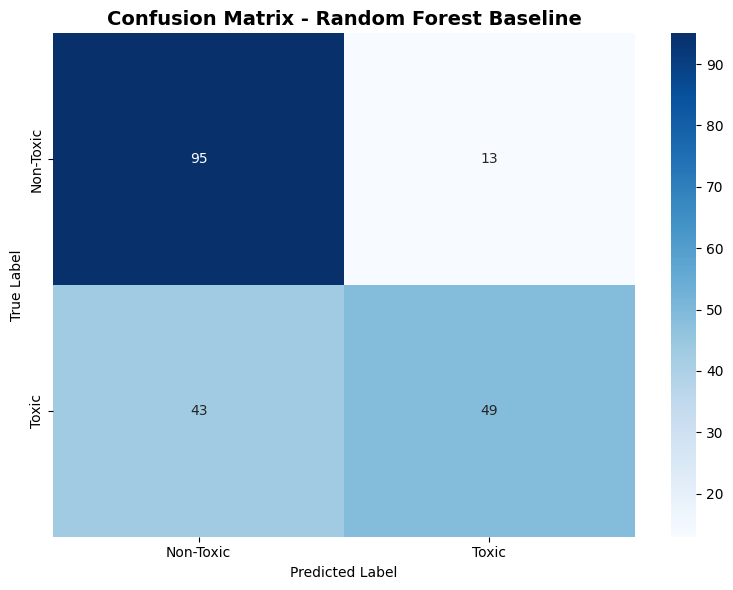


Confusion Matrix Interpretation:
  True Negatives:  95 (Correctly predicted non-toxic)
  False Positives: 13 (Non-toxic predicted as toxic)
  False Negatives: 43 (Toxic predicted as non-toxic)
  True Positives:  49 (Correctly predicted toxic)


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Confusion Matrix - Random Forest Baseline', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives:  {cm[0,0]} (Correctly predicted non-toxic)")
print(f"  False Positives: {cm[0,1]} (Non-toxic predicted as toxic)")
print(f"  False Negatives: {cm[1,0]} (Toxic predicted as non-toxic)")
print(f"  True Positives:  {cm[1,1]} (Correctly predicted toxic)")

## 6. Feature Importance Analysis

In [12]:
# Get feature importance
feature_importance = rf_baseline.feature_importances_
feature_names = tfidf_bigram.get_feature_names_out()

# Create dataframe and sort
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n🎯 Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


🎯 Top 20 Most Important Features:
feature  importance
    run    0.026860
   fuck    0.022135
   shit    0.020463
  idiot    0.019514
  bitch    0.012475
fucking    0.012267
   thug    0.010633
 stupid    0.010536
    cnn    0.010356
  shoot    0.009497
    not    0.009281
     as    0.009249
  white    0.008716
  video    0.008361
  black    0.008279
   dumb    0.007783
    get    0.007240
  thank    0.006717
  brown    0.006619
   kill    0.005978


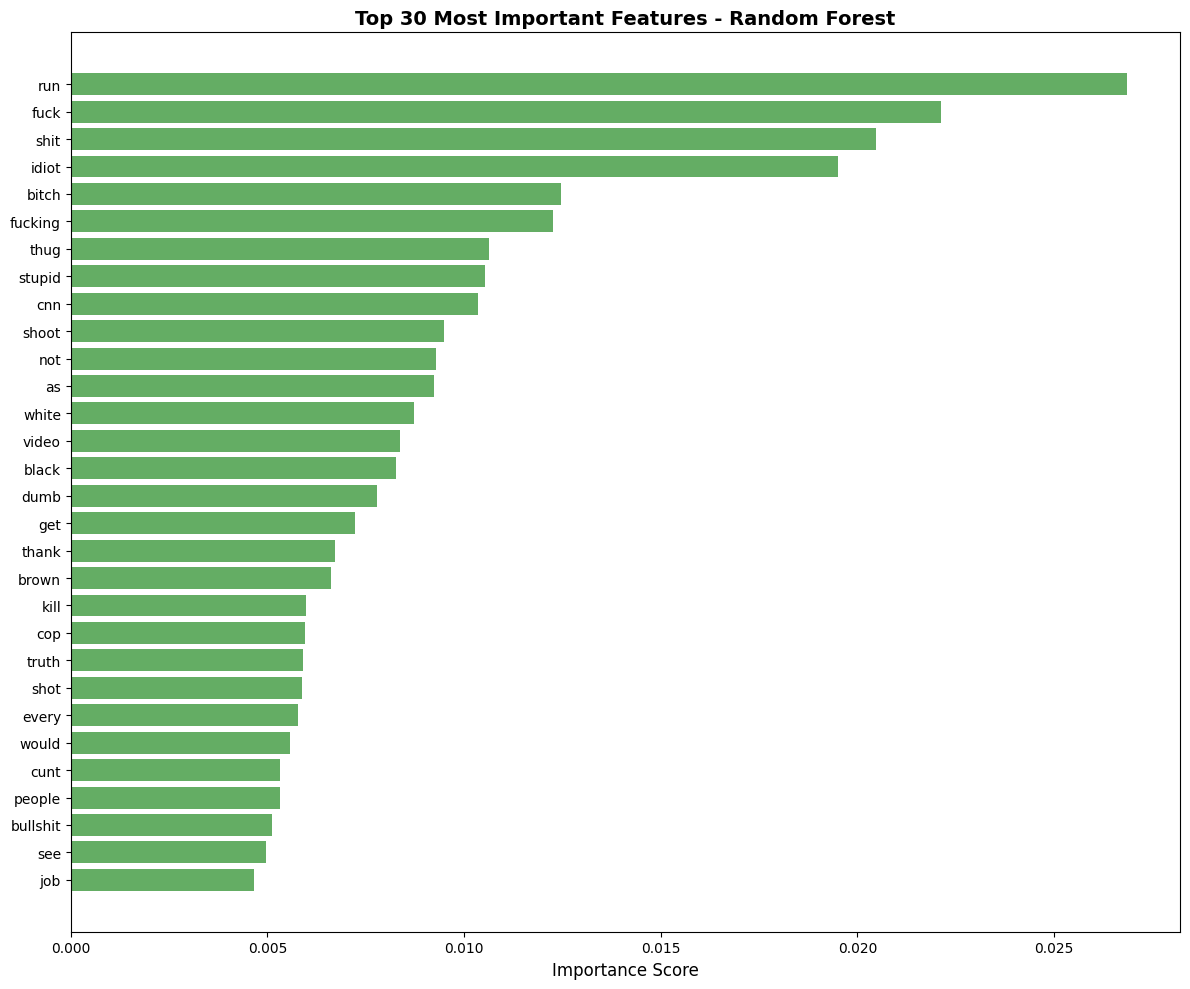

In [13]:
# Visualize top 30 features
top_n = 30
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 10))
plt.barh(range(top_n), top_features['importance'].values, color='forestgreen', alpha=0.7)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top {top_n} Most Important Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. ROC Curve and Precision-Recall Curve

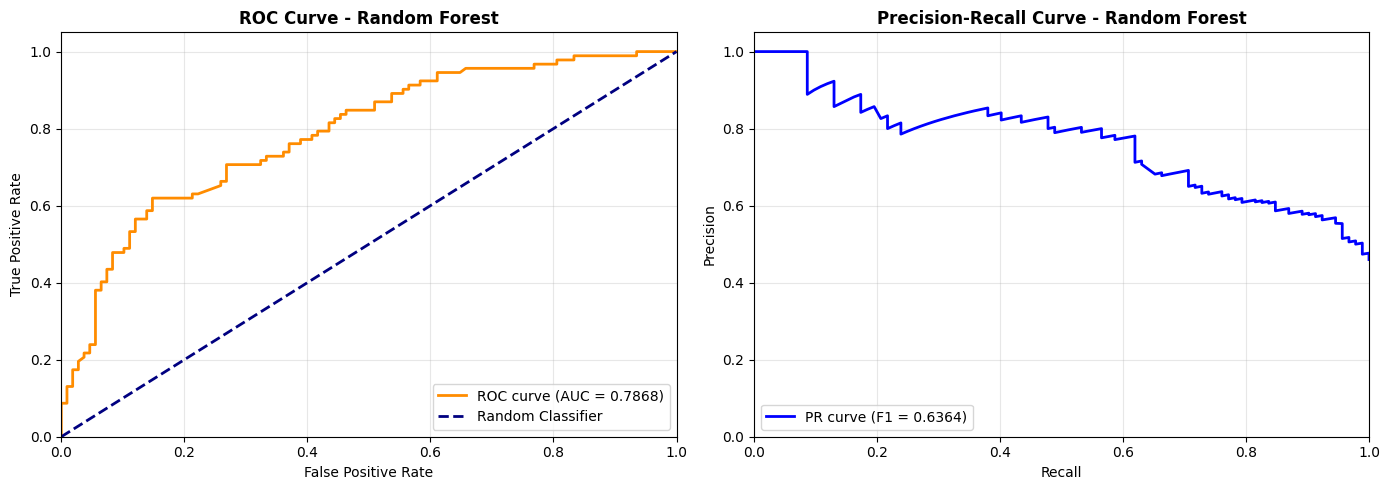

In [14]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (F1 = {test_f1:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Random Forest', fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Cross-Validation

In [15]:
print("🔄 Performing 5-Fold Cross-Validation...")
print("This may take 5-10 minutes...\n")

cv_start = time.time()

# Stratified K-Fold for imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=skf, 
                            scoring='f1', n_jobs=-1)

cv_time = time.time() - cv_start

print(f"✅ Cross-Validation completed in {cv_time:.2f} seconds")
print(f"\nCV F1-Scores: {cv_scores}")
print(f"Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

🔄 Performing 5-Fold Cross-Validation...
This may take 5-10 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurre

✅ Cross-Validation completed in 368.59 seconds

CV F1-Scores: [0.71428571 0.64788732 0.68148148 0.62686567 0.66666667]
Mean CV F1-Score: 0.6674 (+/- 0.0297)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


## 9. Optimized Random Forest with Tuned Parameters

In [16]:
print("\n🌲 Training Optimized Random Forest...")
print("Using tuned hyperparameters for better performance\n")

start_time = time.time()

# Optimized parameters based on common best practices
rf_optimized = RandomForestClassifier(
    n_estimators=200,           # More trees for better performance
    max_depth=30,               # Control overfitting
    min_samples_split=5,        # Minimum samples to split
    min_samples_leaf=2,         # Minimum samples at leaf
    max_features='sqrt',        # Features to consider for split
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train optimized model
rf_optimized.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds")


🌲 Training Optimized Random Forest...
Using tuned hyperparameters for better performance



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.5s



✅ Training completed in 2.64 seconds


[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.1s finished


## 10. Evaluate Optimized Model

In [17]:
# Make predictions
y_train_pred_opt = rf_optimized.predict(X_train)
y_test_pred_opt = rf_optimized.predict(X_test)

y_train_proba_opt = rf_optimized.predict_proba(X_train)[:, 1]
y_test_proba_opt = rf_optimized.predict_proba(X_test)[:, 1]

# Calculate metrics
print("\n" + "="*80)
print("📊 RANDOM FOREST - OPTIMIZED RESULTS")
print("="*80)

print("\n🔵 Training Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_opt):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_opt):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_opt):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba_opt):.4f}")

print("\n🟢 Test Set:")
test_acc_opt = accuracy_score(y_test, y_test_pred_opt)
test_prec_opt = precision_score(y_test, y_test_pred_opt)
test_rec_opt = recall_score(y_test, y_test_pred_opt)
test_f1_opt = f1_score(y_test, y_test_pred_opt)
test_auc_opt = roc_auc_score(y_test, y_test_proba_opt)

print(f"  Accuracy:  {test_acc_opt:.4f}")
print(f"  Precision: {test_prec_opt:.4f}")
print(f"  Recall:    {test_rec_opt:.4f}")
print(f"  F1-Score:  {test_f1_opt:.4f}")
print(f"  ROC-AUC:   {test_auc_opt:.4f}")

# Check for overfitting
overfit_diff_opt = accuracy_score(y_train, y_train_pred_opt) - test_acc_opt
print(f"\n⚠️  Overfitting Check:")
print(f"  Train-Test Accuracy Difference: {overfit_diff_opt:.4f} ({overfit_diff_opt*100:.2f}%)")
if overfit_diff_opt < 0.05:
    print("  ✅ Good generalization (< 5% difference)")
else:
    print("  ⚠️  Possible overfitting (≥ 5% difference)")


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      |


📊 RANDOM FOREST - OPTIMIZED RESULTS

🔵 Training Set:
  Accuracy:  0.8975
  Precision: 0.9472
  Recall:    0.8243
  F1-Score:  0.8815
  ROC-AUC:   0.9752

🟢 Test Set:
  Accuracy:  0.7200
  Precision: 0.7812
  Recall:    0.5435
  F1-Score:  0.6410
  ROC-AUC:   0.8214

⚠️  Overfitting Check:
  Train-Test Accuracy Difference: 0.1775 (17.75%)
  ⚠️  Possible overfitting (≥ 5% difference)


In [18]:
# Compare baseline vs optimized
print("\n" + "="*80)
print("📊 BASELINE vs OPTIMIZED COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Overfit Gap'],
    'Baseline': [test_acc, test_prec, test_rec, test_f1, test_auc, overfit_diff],
    'Optimized': [test_acc_opt, test_prec_opt, test_rec_opt, test_f1_opt, test_auc_opt, overfit_diff_opt],
    'Improvement': [
        test_acc_opt - test_acc,
        test_prec_opt - test_prec,
        test_rec_opt - test_rec,
        test_f1_opt - test_f1,
        test_auc_opt - test_auc,
        overfit_diff - overfit_diff_opt
    ]
})

display(comparison_df)


📊 BASELINE vs OPTIMIZED COMPARISON


,Metric,Baseline,Optimized,Improvement
0,Accuracy,0.720000,0.720000,0.000000
1,Precision,0.790323,0.781250,-0.009073
2,Recall,0.532609,0.543478,0.010870
3,F1-Score,0.636364,0.641026,0.004662
4,ROC-AUC,0.786836,0.821357,0.034521
5,Overfit Gap,0.276250,0.177500,0.098750


## 11. Save Model and Results

In [19]:
# Save the optimized model
joblib.dump(rf_optimized, 'random_forest_model.pkl')
print("✅ Model saved as 'random_forest_model.pkl'")

# Save results
results = {
    'model_name': 'Random Forest',
    'training_time': training_time,
    'test_accuracy': test_acc_opt,
    'test_precision': test_prec_opt,
    'test_recall': test_rec_opt,
    'test_f1': test_f1_opt,
    'test_roc_auc': test_auc_opt,
    'cv_f1_mean': cv_scores.mean(),
    'cv_f1_std': cv_scores.std(),
    'overfit_gap': overfit_diff_opt,
    'n_features': X_train.shape[1],
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to JSON
import json
with open('random_forest_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✅ Results saved as 'random_forest_results.json'")

✅ Model saved as 'random_forest_model.pkl'
✅ Results saved as 'random_forest_results.json'


## 12. Model Summary

In [20]:
print("\n" + "="*80)
print("📋 RANDOM FOREST MODEL SUMMARY")
print("="*80)

print(f"\n✅ Model Type: Random Forest Classifier (Ensemble)")
print(f"✅ Features: TF-IDF Bigrams ({X_train.shape[1]} features)")
print(f"✅ Training samples: {X_train.shape[0]}")  # Changed from len(X_train)
print(f"✅ Test samples: {X_test.shape[0]}")      # Changed from len(X_test)

print(f"\n📊 Best Performance Metrics:")
print(f"  - Test Accuracy:  {test_acc_opt:.4f}")
print(f"  - Test F1-Score:  {test_f1_opt:.4f}")
print(f"  - Test ROC-AUC:   {test_auc_opt:.4f}")
print(f"  - CV F1-Score:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Overfit Gap:    {overfit_diff_opt:.4f} ({overfit_diff_opt*100:.2f}%)")

print(f"\n⏱️  Training Time: {training_time:.2f} seconds")

print("\n🎯 Next Steps:")
print("  1. Train XGBoost model for comparison")
print("  2. Compare with other classical ML models")
print("  3. Try hyperparameter tuning with Optuna")
print("  4. Implement neural networks (LSTM, Transformers)")

print("\n✅ Random Forest training complete!")
print("="*80)


📋 RANDOM FOREST MODEL SUMMARY

✅ Model Type: Random Forest Classifier (Ensemble)
✅ Features: TF-IDF Bigrams (2601 features)
✅ Training samples: 800
✅ Test samples: 200

📊 Best Performance Metrics:
  - Test Accuracy:  0.7200
  - Test F1-Score:  0.6410
  - Test ROC-AUC:   0.8214
  - CV F1-Score:    0.6674 (+/- 0.0297)
  - Overfit Gap:    0.1775 (17.75%)

⏱️  Training Time: 2.64 seconds

🎯 Next Steps:
  1. Train XGBoost model for comparison
  2. Compare with other classical ML models
  3. Try hyperparameter tuning with Optuna
  4. Implement neural networks (LSTM, Transformers)

✅ Random Forest training complete!
